# 10. Detecting Bad Controls, Post-Treatment Variables, and Leakage

In prediction work, a variable is useful if it improves out-of-sample accuracy. In causal inference, that rule is not enough. A variable can be highly predictive and still be a bad control.

This notebook focuses on one of the most common ways industry causal analyses break: variables measured after treatment, variables on the causal pathway, selection variables, colliders, and features that leak future information are accidentally included as controls.

The AI-assisted workflow in this notebook is deliberately cautious. Python builds timing and sensitivity evidence. The LLM helps review variable roles and surface warnings. Then deterministic audit rules check whether the model recommended something dangerous.

## Learning Goals

By the end of this notebook you should be able to:

1. Explain why a variable can be predictive but invalid for causal adjustment.
2. Distinguish pre-treatment confounders, mediators, descendants of treatment, colliders, outcomes, and future leakage variables.
3. Use timing metadata to build an automated first-pass bad-control scan.
4. Show how treatment coefficients change when bad controls are added.
5. Build an AI review prompt that asks for variable-role classification, not causal effect estimation.
6. Audit model outputs for dangerous recommendations such as adjusting for mediators or future variables.
7. Compare several local LLMs and treat brittle outputs as observable workflow evidence.

## Live Model Note

This course treats LLM behavior as an empirical object. These notebooks may include live local-model calls, so outputs can vary across model versions, hardware, decoding settings, prompt wording, package versions, and reruns. That instability is part of the lesson: AI-assisted causal work needs deterministic checks, structured outputs, model comparison, repair logic, and human review.

This notebook is especially brittle because bad-control detection requires causal role reasoning. A model may correctly notice that `future_60d_revenue` is leakage but still recommend adjusting for `clicked_offer`; another model may identify mediators but miss the survey-selection collider. We will not hide those failures. We will score and discuss them.

## 1. Setup

The deterministic sections use simulated product-growth data. The optional live-model sections use the shared local LLM runtime already used in Course 05.

The main estimand is the **total effect** of receiving a premium-offer nudge on 30-day revenue. For that estimand, variables caused by the offer should not be adjusted for in the primary model.

In [1]:
import importlib.util
import json
import sys
import textwrap
import warnings
from pathlib import Path
from typing import Literal

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.formula.api as smf
import torch
from IPython.display import Markdown, display
from pydantic import BaseModel, Field
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore', category=FutureWarning)

In [2]:
RUN_LIVE_LOCAL_LLM = True
RUN_FULL_MODEL_COMPARISON = True
RUN_SCHEMA_REPAIR_RETRY = True

LOCAL_SMOKE_TEST_MODEL = 'Qwen/Qwen2.5-0.5B-Instruct'
LOCAL_FAST_MODEL = 'Qwen/Qwen2.5-7B-Instruct'
LOCAL_STRONG_MODEL = 'Qwen/Qwen2.5-14B-Instruct'
LOCAL_SCALE_MODEL = 'Qwen/Qwen2.5-32B-Instruct'

LOCAL_ALT_REASONING_MODEL = 'microsoft/Phi-3.5-mini-instruct'
LOCAL_ALT_OPEN_MODEL = 'mistralai/Mistral-7B-Instruct-v0.3'
LOCAL_MISTRAL_SMALL_MODEL = 'mistralai/Mistral-Small-3.1-24B-Instruct-2503'
LOCAL_GEMMA_MODEL = 'google/gemma-3-27b-it'
LOCAL_LLAMA_MODEL = 'meta-llama/Meta-Llama-3.1-8B-Instruct'

MODEL_ID = LOCAL_FAST_MODEL
MAX_NEW_TOKENS = 1800
TEMPERATURE = 0.0
SEED = 210
MODEL_COMPARISON_CASE_LIMIT = 1

MODELS_TO_COMPARE = [
    ('Qwen 0.5B', LOCAL_SMOKE_TEST_MODEL, 'pipeline smoke test'),
    ('Qwen 7B', LOCAL_FAST_MODEL, 'fast default'),
    ('Qwen 14B', LOCAL_STRONG_MODEL, 'strong local analysis'),
    ('Qwen 32B', LOCAL_SCALE_MODEL, 'scale comparison'),
    ('Phi mini', LOCAL_ALT_REASONING_MODEL, 'compact non-Qwen comparison'),
    ('Mistral 7B', LOCAL_ALT_OPEN_MODEL, '7B model-family comparison'),
    ('Mistral Small 24B', LOCAL_MISTRAL_SMALL_MODEL, 'strong non-Qwen comparison'),
    ('Gemma 3 27B', LOCAL_GEMMA_MODEL, 'large non-Qwen comparison'),
    ('Llama 3.1 8B', LOCAL_LLAMA_MODEL, 'industry-standard instruct baseline'),
]

np.random.seed(SEED)
sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_colwidth', 150)

In [3]:
def has_package(module_name):
    return importlib.util.find_spec(module_name) is not None

package_status = pd.DataFrame(
    [
        {'package': 'pandas', 'available': has_package('pandas'), 'used_for': 'role tables and diagnostics'},
        {'package': 'statsmodels', 'available': has_package('statsmodels'), 'used_for': 'coefficient sensitivity regressions'},
        {'package': 'sklearn', 'available': has_package('sklearn'), 'used_for': 'prediction leakage demonstration'},
        {'package': 'pydantic', 'available': has_package('pydantic'), 'used_for': 'structured AI review schema'},
        {'package': 'transformers', 'available': has_package('transformers'), 'used_for': 'optional local LLM review'},
        {'package': 'torch', 'available': has_package('torch'), 'used_for': 'GPU inference if live LLMs are enabled'},
    ]
)

print(f'CUDA available to this kernel: {torch.cuda.is_available()}')
package_status

CUDA available to this kernel: True


,package,available,used_for
0,pandas,True,role tables and diagnostics
1,statsmodels,True,coefficient sensitivity regressions
2,sklearn,True,prediction leakage demonstration
3,pydantic,True,structured AI review schema
4,transformers,True,optional local LLM review
5,torch,True,GPU inference if live LLMs are enabled


## 2. Bad Controls in One Picture

A control variable is not good merely because it is associated with the outcome. Whether we should adjust for a variable depends on its role in the causal structure.

For the total effect of a treatment `T` on outcome `Y`:

- Adjusting for a **pre-treatment confounder** can reduce bias.
- Adjusting for a **mediator** blocks part of the effect.
- Adjusting for a **descendant of treatment** can change the estimand or introduce bias.
- Adjusting for a **collider** can open a non-causal path.
- Adjusting for **future information** leaks outcome information into the model.

The hard part in practice is that column names rarely announce their causal role. Timing metadata and domain review are essential.

In [4]:
role_principles = pd.DataFrame(
    [
        {
            'variable role': 'Pre-treatment confounder',
            'example': 'baseline_spend, pre_activity, tenure_days',
            'adjust for total effect?': 'usually eligible, subject to DAG review',
            'why': 'Common cause of treatment and outcome.',
        },
        {
            'variable role': 'Mediator',
            'example': 'opened_offer, clicked_offer, upgrade_started',
            'adjust for total effect?': 'no',
            'why': 'Part of the pathway from treatment to outcome.',
        },
        {
            'variable role': 'Post-treatment descendant',
            'example': 'sessions_after_offer, support_contacts_after_offer',
            'adjust for total effect?': 'no',
            'why': 'May be affected by treatment and may proxy the outcome pathway.',
        },
        {
            'variable role': 'Collider or selection variable',
            'example': 'survey_completed, observed_only_if_active',
            'adjust for total effect?': 'no without explicit design',
            'why': 'Conditioning can create artificial associations.',
        },
        {
            'variable role': 'Outcome or guardrail',
            'example': 'revenue_30d, satisfaction_30d',
            'adjust for total effect?': 'no',
            'why': 'It is what the treatment may change.',
        },
        {
            'variable role': 'Future leakage',
            'example': 'future_60d_revenue, next_month_activity',
            'adjust for total effect?': 'no',
            'why': 'Measured after the outcome window or using future labels.',
        },
    ]
)
role_principles

,variable role,example,adjust for total effect?,why
0,Pre-treatment confounder,"baseline_spend, pre_activity, tenure_days","usually eligible, subject to DAG review",Common cause of treatment and outcome.
1,Mediator,"opened_offer, clicked_offer, upgrade_started",no,Part of the pathway from treatment to outcome.
2,Post-treatment descendant,"sessions_after_offer, support_contacts_after_offer",no,May be affected by treatment and may proxy the outcome pathway.
3,Collider or selection variable,"survey_completed, observed_only_if_active",no without explicit design,Conditioning can create artificial associations.
4,Outcome or guardrail,"revenue_30d, satisfaction_30d",no,It is what the treatment may change.
5,Future leakage,"future_60d_revenue, next_month_activity",no,Measured after the outcome window or using future labels.


### Discussion

The same variable can have different roles under different estimands. If the estimand is the total effect of being offered a promotion, `clicked_offer` is a mediator. If the estimand is the effect of actually clicking among those offered, `clicked_offer` becomes the treatment or exposure. This is why role detection must be tied to a stated estimand.

## 3. Running Example: Premium Offer Nudge

A product team sends a premium-offer nudge to selected users. The business asks:

> What is the total effect of receiving the premium-offer nudge on 30-day revenue?

This is an observational targeting problem. Users with higher baseline engagement and higher predicted upgrade propensity are more likely to receive the nudge. The dataset also contains variables measured after the nudge, because product analytics systems often record everything in one wide table.

In [5]:
def simulate_premium_offer_data(n=5000, seed=SEED):
    rng = np.random.default_rng(seed)
    region = rng.choice(['Americas', 'EMEA', 'APAC'], size=n, p=[0.48, 0.32, 0.20])
    acquisition_channel = rng.choice(['organic', 'paid_search', 'partner', 'referral'], size=n, p=[0.38, 0.30, 0.17, 0.15])
    tenure_days = rng.gamma(shape=3.2, scale=65, size=n).clip(7, 900)
    baseline_activity = rng.normal(0, 1, size=n)
    baseline_spend = np.exp(2.15 + 0.28 * baseline_activity + 0.18 * (acquisition_channel == 'paid_search') + rng.normal(0, 0.45, size=n))
    price_sensitivity = rng.normal(0, 1, size=n) - 0.20 * baseline_activity + 0.25 * (region == 'APAC')
    pre_support_tickets = rng.poisson(np.exp(-0.15 + 0.25 * baseline_activity + 0.18 * (acquisition_channel == 'partner')))
    predicted_upgrade_score = (
        0.55 * baseline_activity
        + 0.32 * np.log1p(baseline_spend)
        - 0.25 * price_sensitivity
        + 0.18 * (tenure_days > 120)
        + rng.normal(0, 0.55, size=n)
    )
    targeting_logit = -0.35 + 0.85 * predicted_upgrade_score + 0.25 * (region == 'Americas') + 0.20 * (acquisition_channel == 'paid_search')
    offer_probability = 1 / (1 + np.exp(-targeting_logit))
    premium_offer_nudge = rng.binomial(1, offer_probability)

    opened_offer = rng.binomial(1, 1 / (1 + np.exp(-(-0.7 + 1.1 * premium_offer_nudge + 0.45 * baseline_activity - 0.25 * price_sensitivity))))
    clicked_offer = rng.binomial(1, 1 / (1 + np.exp(-(-1.35 + 1.25 * premium_offer_nudge + 1.1 * opened_offer + 0.35 * predicted_upgrade_score))))
    upgrade_started = rng.binomial(1, 1 / (1 + np.exp(-(-1.7 + 1.6 * clicked_offer + 0.45 * predicted_upgrade_score - 0.35 * price_sensitivity))))
    sessions_after_offer = (
        4.5
        + 1.8 * baseline_activity
        + 1.3 * premium_offer_nudge
        + 2.2 * clicked_offer
        + rng.normal(0, 1.9, size=n)
    ).clip(0, None)

    true_total_effect = 4.8 + 1.4 * np.maximum(baseline_activity, 0) - 1.1 * np.maximum(price_sensitivity, 0)
    revenue_30d = (
        18
        + 0.62 * baseline_spend
        + 3.2 * baseline_activity
        - 1.7 * price_sensitivity
        + 1.1 * pre_support_tickets
        + premium_offer_nudge * true_total_effect
        + 3.5 * upgrade_started
        + rng.normal(0, 8.0, size=n)
    )
    customer_complaint_30d = rng.binomial(1, 1 / (1 + np.exp(-(-2.2 + 0.28 * price_sensitivity + 0.22 * pre_support_tickets + 0.12 * premium_offer_nudge))))
    satisfaction_30d = (82 + 2.2 * baseline_activity - 5.2 * customer_complaint_30d + 0.5 * premium_offer_nudge + rng.normal(0, 4, size=n)).clip(35, 100)

    survey_completed = rng.binomial(1, 1 / (1 + np.exp(-(-1.1 + 0.55 * premium_offer_nudge + 0.035 * revenue_30d - 0.25 * customer_complaint_30d))))
    future_60d_revenue = revenue_30d + 0.42 * baseline_spend + 5.0 * upgrade_started + rng.normal(0, 10, size=n)
    next_month_activity = sessions_after_offer + 0.07 * revenue_30d + rng.normal(0, 2.0, size=n)
    post_outcome_model_score = 0.55 * future_60d_revenue + 8.5 * upgrade_started + rng.normal(0, 3.0, size=n)

    df = pd.DataFrame(
        {
            'user_id': [f'U{idx:05d}' for idx in range(n)],
            'region': region,
            'acquisition_channel': acquisition_channel,
            'tenure_days': tenure_days,
            'baseline_activity': baseline_activity,
            'baseline_spend': baseline_spend,
            'price_sensitivity': price_sensitivity,
            'pre_support_tickets': pre_support_tickets,
            'predicted_upgrade_score': predicted_upgrade_score,
            'premium_offer_nudge': premium_offer_nudge,
            'opened_offer': opened_offer,
            'clicked_offer': clicked_offer,
            'upgrade_started': upgrade_started,
            'sessions_after_offer': sessions_after_offer,
            'revenue_30d': revenue_30d,
            'customer_complaint_30d': customer_complaint_30d,
            'satisfaction_30d': satisfaction_30d,
            'survey_completed': survey_completed,
            'future_60d_revenue': future_60d_revenue,
            'next_month_activity': next_month_activity,
            'post_outcome_model_score': post_outcome_model_score,
        }
    )

    missing_price = (df['region'].eq('APAC') & (rng.uniform(size=n) < 0.10)) | ((df['acquisition_channel'].eq('partner')) & (rng.uniform(size=n) < 0.06))
    df.loc[missing_price, 'price_sensitivity'] = np.nan
    missing_satisfaction = (df['survey_completed'].eq(0)) | ((df['customer_complaint_30d'].eq(1)) & (rng.uniform(size=n) < 0.15))
    df.loc[missing_satisfaction, 'satisfaction_30d'] = np.nan
    return df

raw = simulate_premium_offer_data()
raw.head()

,user_id,region,acquisition_channel,tenure_days,baseline_activity,baseline_spend,price_sensitivity,pre_support_tickets,predicted_upgrade_score,premium_offer_nudge,...,clicked_offer,upgrade_started,sessions_after_offer,revenue_30d,customer_complaint_30d,satisfaction_30d,survey_completed,future_60d_revenue,next_month_activity,post_outcome_model_score
0,U00000,EMEA,paid_search,165.562716,0.034172,7.537197,1.471302,1,0.742065,0,...,0,0,7.299572,18.772712,0,NaN,0,28.173530,9.882633,11.441728
1,U00001,EMEA,organic,186.206172,0.490043,2.383664,1.952122,0,0.537754,0,...,0,0,5.556472,28.127816,0,NaN,0,30.692014,9.379624,20.908481
2,U00002,Americas,paid_search,343.626247,-1.792142,7.371139,0.104702,1,1.226725,0,...,0,0,0.000000,27.996731,0,77.599901,1,37.818629,-1.903540,23.639899
3,U00003,EMEA,paid_search,314.156981,1.594735,8.618884,0.232738,1,2.087897,0,...,1,0,11.111103,39.900662,0,NaN,0,52.431925,12.779653,26.107596
4,U00004,Americas,partner,306.396885,0.486046,18.874761,0.116731,1,1.054545,0,...,0,0,4.555457,33.238375,0,81.057657,1,34.803663,7.478922,17.373958


In [6]:
data_dictionary = pd.DataFrame(
    [
        {'variable': 'user_id', 'description': 'User identifier.', 'timing': 'unit id', 'role_for_total_effect': 'unit identifier'},
        {'variable': 'region', 'description': 'User operating region before targeting.', 'timing': 'pre-treatment', 'role_for_total_effect': 'candidate confounder'},
        {'variable': 'acquisition_channel', 'description': 'Original acquisition channel.', 'timing': 'pre-treatment', 'role_for_total_effect': 'candidate confounder'},
        {'variable': 'tenure_days', 'description': 'Days since signup before the campaign decision.', 'timing': 'pre-treatment', 'role_for_total_effect': 'candidate confounder'},
        {'variable': 'baseline_activity', 'description': 'Pre-campaign engagement score.', 'timing': 'pre-treatment', 'role_for_total_effect': 'candidate confounder'},
        {'variable': 'baseline_spend', 'description': 'Pre-campaign average spend.', 'timing': 'pre-treatment', 'role_for_total_effect': 'candidate confounder'},
        {'variable': 'price_sensitivity', 'description': 'Pre-campaign estimated price sensitivity.', 'timing': 'pre-treatment', 'role_for_total_effect': 'candidate confounder'},
        {'variable': 'pre_support_tickets', 'description': 'Support tickets before the campaign.', 'timing': 'pre-treatment', 'role_for_total_effect': 'candidate confounder'},
        {'variable': 'predicted_upgrade_score', 'description': 'Targeting score computed before the offer.', 'timing': 'pre-treatment', 'role_for_total_effect': 'candidate confounder or assignment proxy'},
        {'variable': 'premium_offer_nudge', 'description': 'Whether the user received the premium-offer nudge.', 'timing': 'treatment', 'role_for_total_effect': 'treatment'},
        {'variable': 'opened_offer', 'description': 'Whether the user opened the offer message.', 'timing': 'post-treatment', 'role_for_total_effect': 'mediator or compliance behavior'},
        {'variable': 'clicked_offer', 'description': 'Whether the user clicked through the offer.', 'timing': 'post-treatment', 'role_for_total_effect': 'mediator'},
        {'variable': 'upgrade_started', 'description': 'Whether the user started an upgrade flow after the offer.', 'timing': 'post-treatment', 'role_for_total_effect': 'mediator'},
        {'variable': 'sessions_after_offer', 'description': 'User activity after the offer during the outcome window.', 'timing': 'post-treatment', 'role_for_total_effect': 'post-treatment descendant'},
        {'variable': 'revenue_30d', 'description': 'Revenue in the 30-day outcome window.', 'timing': 'outcome window', 'role_for_total_effect': 'primary outcome'},
        {'variable': 'customer_complaint_30d', 'description': 'Customer complaint indicator during the 30-day outcome window.', 'timing': 'outcome window', 'role_for_total_effect': 'guardrail outcome'},
        {'variable': 'satisfaction_30d', 'description': 'Satisfaction among users with observed surveys.', 'timing': 'outcome window', 'role_for_total_effect': 'guardrail outcome with selection'},
        {'variable': 'survey_completed', 'description': 'Whether a satisfaction survey was observed.', 'timing': 'post-outcome selection', 'role_for_total_effect': 'collider or selection variable'},
        {'variable': 'future_60d_revenue', 'description': 'Revenue over a longer future horizon.', 'timing': 'future', 'role_for_total_effect': 'future leakage'},
        {'variable': 'next_month_activity', 'description': 'Activity after the 30-day window.', 'timing': 'future', 'role_for_total_effect': 'future leakage'},
        {'variable': 'post_outcome_model_score', 'description': 'Score produced from data after the outcome window.', 'timing': 'future', 'role_for_total_effect': 'future leakage'},
    ]
)

data_dictionary

,variable,description,timing,role_for_total_effect
0,user_id,User identifier.,unit id,unit identifier
1,region,User operating region before targeting.,pre-treatment,candidate confounder
2,acquisition_channel,Original acquisition channel.,pre-treatment,candidate confounder
3,tenure_days,Days since signup before the campaign decision.,pre-treatment,candidate confounder
4,baseline_activity,Pre-campaign engagement score.,pre-treatment,candidate confounder
5,baseline_spend,Pre-campaign average spend.,pre-treatment,candidate confounder
6,price_sensitivity,Pre-campaign estimated price sensitivity.,pre-treatment,candidate confounder
7,pre_support_tickets,Support tickets before the campaign.,pre-treatment,candidate confounder
8,predicted_upgrade_score,Targeting score computed before the offer.,pre-treatment,candidate confounder or assignment proxy
9,premium_offer_nudge,Whether the user received the premium-offer nudge.,treatment,treatment


### Discussion

The data dictionary gives the model and the analyst something that raw correlations cannot: time. A variable like `predicted_upgrade_score` is valid only because it was computed before targeting. A variable like `post_outcome_model_score` may look like a normal ML score, but its timestamp makes it leakage.

## 4. A Timing-Based Bad-Control Scan

A first-pass scan can classify variables by timing and declared role. This is not a substitute for a DAG, but it catches many dangerous mistakes before model fitting.

In [7]:
def classify_adjustment_eligibility(row):
    timing = row['timing']
    role = row['role_for_total_effect']
    if timing == 'pre-treatment':
        return 'eligible candidate, subject to causal graph review'
    if role == 'treatment':
        return 'not a control: treatment'
    if timing in {'post-treatment', 'outcome window', 'post-outcome selection', 'future'}:
        return 'exclude from primary total-effect adjustment'
    return 'not an adjustment variable'

role_scan = data_dictionary.copy()
role_scan['primary_total_effect_adjustment_status'] = role_scan.apply(classify_adjustment_eligibility, axis=1)
role_scan[['variable', 'timing', 'role_for_total_effect', 'primary_total_effect_adjustment_status']]

,variable,timing,role_for_total_effect,primary_total_effect_adjustment_status
0,user_id,unit id,unit identifier,not an adjustment variable
1,region,pre-treatment,candidate confounder,"eligible candidate, subject to causal graph review"
2,acquisition_channel,pre-treatment,candidate confounder,"eligible candidate, subject to causal graph review"
3,tenure_days,pre-treatment,candidate confounder,"eligible candidate, subject to causal graph review"
4,baseline_activity,pre-treatment,candidate confounder,"eligible candidate, subject to causal graph review"
5,baseline_spend,pre-treatment,candidate confounder,"eligible candidate, subject to causal graph review"
6,price_sensitivity,pre-treatment,candidate confounder,"eligible candidate, subject to causal graph review"
7,pre_support_tickets,pre-treatment,candidate confounder,"eligible candidate, subject to causal graph review"
8,predicted_upgrade_score,pre-treatment,candidate confounder or assignment proxy,"eligible candidate, subject to causal graph review"
9,premium_offer_nudge,treatment,treatment,not a control: treatment


In [8]:
role_counts = (
    role_scan
    .groupby(['timing', 'primary_total_effect_adjustment_status'], as_index=False)
    .agg(variables=('variable', 'count'))
)
role_counts

,timing,primary_total_effect_adjustment_status,variables
0,future,exclude from primary total-effect adjustment,3
1,outcome window,exclude from primary total-effect adjustment,3
2,post-outcome selection,exclude from primary total-effect adjustment,1
3,post-treatment,exclude from primary total-effect adjustment,4
4,pre-treatment,"eligible candidate, subject to causal graph review",8
5,treatment,not a control: treatment,1
6,unit id,not an adjustment variable,1


### Discussion

This scan is intentionally conservative. If a variable is post-treatment, outcome-window, selection, or future, it is excluded from the primary total-effect adjustment set. That does not mean the variable is useless. It may be central to a mediation analysis, compliance analysis, guardrail analysis, or diagnostic report. It just should not be quietly added as a covariate in the main total-effect model.

## 5. Why Prediction Can Reward Leakage

A future variable can make prediction look excellent. That is precisely why leakage is so dangerous. The model looks better, the dashboard looks more confident, and the causal interpretation gets worse.

We will compare prediction of `revenue_30d` using only pre-treatment features versus a leaky feature set.

In [9]:
PRE_FEATURES = [
    'region',
    'acquisition_channel',
    'tenure_days',
    'baseline_activity',
    'baseline_spend',
    'price_sensitivity',
    'pre_support_tickets',
    'predicted_upgrade_score',
    'premium_offer_nudge',
]

LEAKY_FEATURES = PRE_FEATURES + [
    'opened_offer',
    'clicked_offer',
    'upgrade_started',
    'sessions_after_offer',
    'future_60d_revenue',
    'next_month_activity',
    'post_outcome_model_score',
]


def fit_prediction_r2(df, features, outcome='revenue_30d', seed=SEED):
    model_df = df[features + [outcome]].dropna().copy()
    X = pd.get_dummies(model_df[features], drop_first=True)
    y = model_df[outcome]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.35, random_state=seed)
    model = LinearRegression()
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    return {
        'feature_set': ' + '.join(features[:3]) + (' ...' if len(features) > 3 else ''),
        'n_features_after_encoding': X.shape[1],
        'rows_used': len(model_df),
        'test_r2': r2_score(y_test, pred),
    }

prediction_comparison = pd.DataFrame(
    [
        {'feature_group': 'pre-treatment only', **fit_prediction_r2(raw, PRE_FEATURES)},
        {'feature_group': 'post-treatment and future leakage included', **fit_prediction_r2(raw, LEAKY_FEATURES)},
    ]
)
prediction_comparison

,feature_group,feature_set,n_features_after_encoding,rows_used,test_r2
0,pre-treatment only,region + acquisition_channel + tenure_days ...,12,4858,0.550923
1,post-treatment and future leakage included,region + acquisition_channel + tenure_days ...,19,4858,0.753295


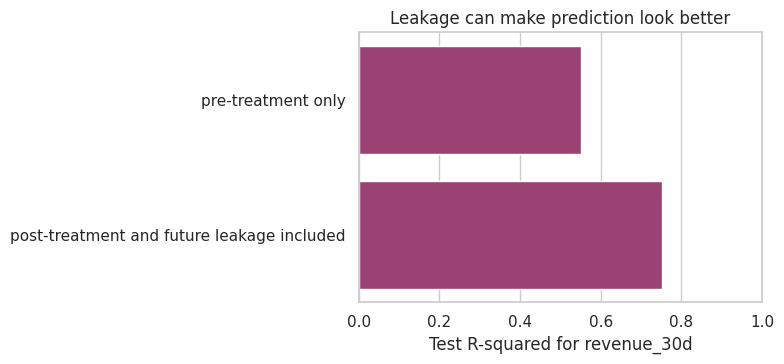

In [10]:
fig, ax = plt.subplots(figsize=(8, 3.8))
sns.barplot(data=prediction_comparison, y='feature_group', x='test_r2', color='#AA3377', ax=ax)
ax.set_xlim(0, 1)
ax.set_title('Leakage can make prediction look better')
ax.set_xlabel('Test R-squared for revenue_30d')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

### Discussion

The leaky feature set is likely to predict `revenue_30d` better because it contains variables from after the treatment or after the outcome window. That is not a victory for causal analysis. It is a warning sign.

A causal assistant should never say, “include `future_60d_revenue` because it improves fit.” The proper response is, “this feature leaks future information and must be excluded from the primary causal adjustment set.”

## 6. Coefficient Sensitivity: Valid Controls versus Bad Controls

Now we fit several regressions for the treatment coefficient. These are not final causal estimates. They are a sensitivity demonstration.

We compare:

1. Naive treated-versus-untreated comparison.
2. Pre-treatment adjustment.
3. Adjustment for mediators and post-treatment descendants.
4. Adjustment for future leakage.
5. Restricting or conditioning on survey completion, a selection variable.

In [11]:
VALID_PRE_CONTROLS = [
    'baseline_activity',
    'baseline_spend',
    'price_sensitivity',
    'pre_support_tickets',
    'predicted_upgrade_score',
    'tenure_days',
]

FORMULAS = {
    'naive': 'revenue_30d ~ premium_offer_nudge',
    'valid pre-treatment adjustment': (
        'revenue_30d ~ premium_offer_nudge + baseline_activity + baseline_spend + price_sensitivity + '
        'pre_support_tickets + predicted_upgrade_score + tenure_days + C(region) + C(acquisition_channel)'
    ),
    'bad mediator adjustment': (
        'revenue_30d ~ premium_offer_nudge + baseline_activity + baseline_spend + price_sensitivity + '
        'pre_support_tickets + predicted_upgrade_score + tenure_days + C(region) + C(acquisition_channel) + '
        'opened_offer + clicked_offer + upgrade_started + sessions_after_offer'
    ),
    'bad future leakage adjustment': (
        'revenue_30d ~ premium_offer_nudge + baseline_activity + baseline_spend + price_sensitivity + '
        'pre_support_tickets + predicted_upgrade_score + tenure_days + C(region) + C(acquisition_channel) + '
        'future_60d_revenue + next_month_activity + post_outcome_model_score'
    ),
    'survey-selected sample': (
        'revenue_30d ~ premium_offer_nudge + baseline_activity + baseline_spend + price_sensitivity + '
        'pre_support_tickets + predicted_upgrade_score + tenure_days + C(region) + C(acquisition_channel)'
    ),
}

coef_rows = []
for label, formula in FORMULAS.items():
    model_df = raw.copy()
    if label == 'survey-selected sample':
        model_df = model_df.query('survey_completed == 1').copy()
    fitted = smf.ols(formula, data=model_df).fit(cov_type='HC3')
    coef_rows.append(
        {
            'specification': label,
            'rows_used': int(fitted.nobs),
            'treatment_coef': fitted.params.get('premium_offer_nudge', np.nan),
            'robust_se': fitted.bse.get('premium_offer_nudge', np.nan),
            'p_value': fitted.pvalues.get('premium_offer_nudge', np.nan),
            'r_squared': fitted.rsquared,
        }
    )

coef_table = pd.DataFrame(coef_rows)
coef_table

,specification,rows_used,treatment_coef,robust_se,p_value,r_squared
0,naive,5000,9.121398,0.318940,6.893766e-180,0.136674
1,valid pre-treatment adjustment,4858,5.147722,0.257348,5.193270e-89,0.545361
2,bad mediator adjustment,4858,4.802489,0.280487,1.017658e-65,0.560184
3,bad future leakage adjustment,4858,2.028347,0.210952,6.897935e-22,0.737190
4,survey-selected sample,2712,5.328864,0.354269,3.903706e-51,0.562570


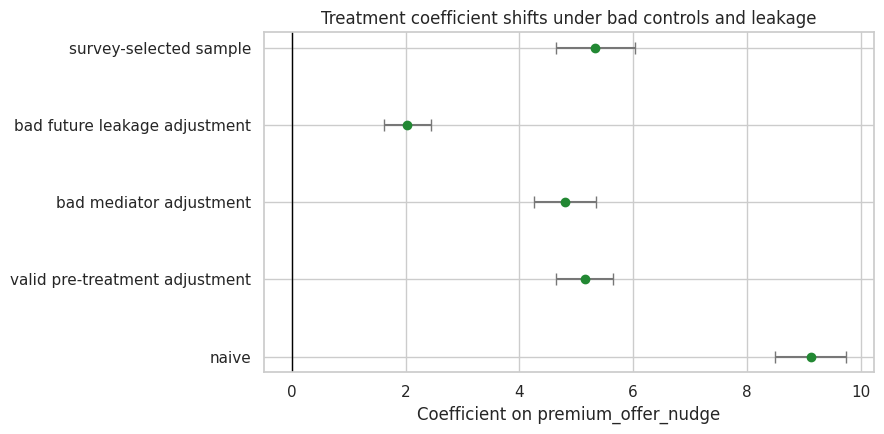

In [12]:
plot_coef = coef_table.assign(
    lower=lambda d: d['treatment_coef'] - 1.96 * d['robust_se'],
    upper=lambda d: d['treatment_coef'] + 1.96 * d['robust_se'],
)
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.errorbar(
    plot_coef['treatment_coef'],
    plot_coef['specification'],
    xerr=[plot_coef['treatment_coef'] - plot_coef['lower'], plot_coef['upper'] - plot_coef['treatment_coef']],
    fmt='o',
    color='#228833',
    ecolor='#777777',
    capsize=4,
)
ax.axvline(0, color='black', linewidth=1)
ax.set_title('Treatment coefficient shifts under bad controls and leakage')
ax.set_xlabel('Coefficient on premium_offer_nudge')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

### Discussion

The mediator-adjusted model is not estimating the same estimand as the pre-treatment model. It blocks pathways through opening, clicking, upgrading, and post-offer activity. The future-leakage model may have very high fit but uses information that would not be available at the treatment decision time and is downstream of the outcome.

The survey-selected sample is a different kind of problem. Survey completion depends on treatment and the outcome process, so conditioning on it can create selection bias. Even if the formula looks reasonable, the sample restriction changes the target population.

## 7. A Mechanical Bad-Control Detector

A simple detector can combine timing metadata, role labels, and correlation patterns. It will not replace a human causal graph, but it creates a repeatable pre-modeling checklist.

In [13]:
def build_bad_control_scan(df, dictionary, treatment='premium_offer_nudge', outcome='revenue_30d'):
    numeric = df.select_dtypes(include='number')
    corr_with_outcome = numeric.corr(numeric_only=True)[outcome].drop(outcome).rename('abs_corr_with_outcome').abs()
    corr_with_treatment = numeric.corr(numeric_only=True)[treatment].drop(treatment).rename('abs_corr_with_treatment').abs()
    scan = dictionary.copy()
    scan = scan.merge(corr_with_outcome.reset_index().rename(columns={'index': 'variable'}), on='variable', how='left')
    scan = scan.merge(corr_with_treatment.reset_index().rename(columns={'index': 'variable'}), on='variable', how='left')
    scan['risk_flag'] = np.select(
        [
            scan['role_for_total_effect'].str.contains('mediator|descendant', case=False, regex=True),
            scan['role_for_total_effect'].str.contains('future leakage', case=False, regex=True),
            scan['role_for_total_effect'].str.contains('collider|selection', case=False, regex=True),
            scan['role_for_total_effect'].str.contains('outcome', case=False, regex=True),
            scan['timing'].eq('pre-treatment'),
        ],
        [
            'bad control risk: mediator or descendant',
            'leakage risk: future information',
            'selection/collider risk',
            'outcome/guardrail: not a control',
            'candidate control: review DAG and positivity',
        ],
        default='not an adjustment variable',
    )
    scan['predictive_but_risky'] = (
        scan['risk_flag'].str.contains('risk|leakage|outcome', case=False, regex=True)
        & (scan['abs_corr_with_outcome'].fillna(0) > 0.15)
    )
    return scan.sort_values(['predictive_but_risky', 'abs_corr_with_outcome'], ascending=[False, False])

bad_control_scan = build_bad_control_scan(raw, data_dictionary)
bad_control_scan[['variable', 'timing', 'role_for_total_effect', 'abs_corr_with_outcome', 'abs_corr_with_treatment', 'risk_flag', 'predictive_but_risky']]

,variable,timing,role_for_total_effect,abs_corr_with_outcome,abs_corr_with_treatment,risk_flag,predictive_but_risky
18,future_60d_revenue,future,future leakage,0.809015,0.313911,leakage risk: future information,True
20,post_outcome_model_score,future,future leakage,0.758386,0.318727,leakage risk: future information,True
19,next_month_activity,future,future leakage,0.588187,0.419182,leakage risk: future information,True
13,sessions_after_offer,post-treatment,post-treatment descendant,0.506061,0.455165,bad control risk: mediator or descendant,True
12,upgrade_started,post-treatment,mediator,0.348386,0.202584,bad control risk: mediator or descendant,True
16,satisfaction_30d,outcome window,guardrail outcome with selection,0.283398,0.151702,selection/collider risk,True
11,clicked_offer,post-treatment,mediator,0.268760,0.396236,bad control risk: mediator or descendant,True
10,opened_offer,post-treatment,mediator or compliance behavior,0.256751,0.297848,bad control risk: mediator or descendant,True
17,survey_completed,post-outcome selection,collider or selection variable,0.236630,0.184140,selection/collider risk,True
4,baseline_activity,pre-treatment,candidate confounder,0.602357,0.229888,candidate control: review DAG and positivity,False


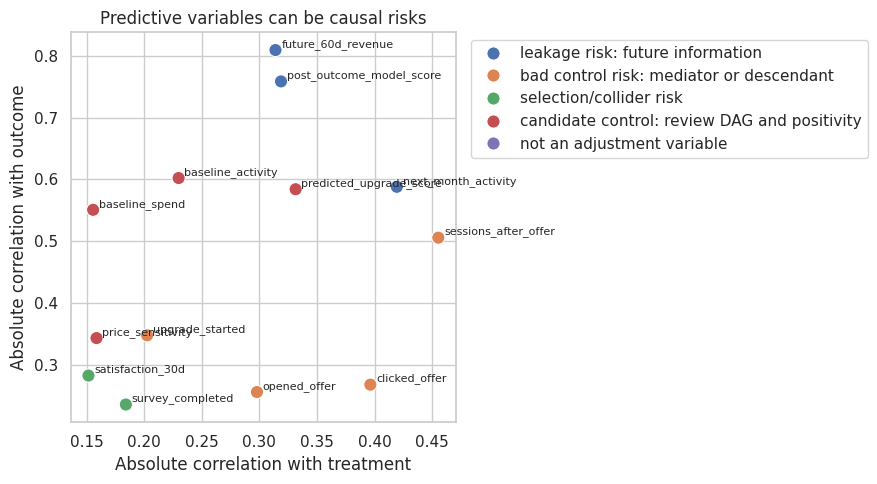

In [14]:
fig, ax = plt.subplots(figsize=(9, 5))
plot_scan = bad_control_scan.dropna(subset=['abs_corr_with_outcome']).head(14).copy()
sns.scatterplot(
    data=plot_scan,
    x='abs_corr_with_treatment',
    y='abs_corr_with_outcome',
    hue='risk_flag',
    s=90,
    ax=ax,
)
for _, row in plot_scan.iterrows():
    ax.text(row['abs_corr_with_treatment'] + 0.005, row['abs_corr_with_outcome'] + 0.005, row['variable'], fontsize=8)
ax.set_title('Predictive variables can be causal risks')
ax.set_xlabel('Absolute correlation with treatment')
ax.set_ylabel('Absolute correlation with outcome')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Discussion

This plot deliberately mixes prediction and causal risk. A variable in the upper-right can be strongly associated with both treatment and outcome. That could be a confounder, but it could also be a mediator, collider, or leakage feature. Timing determines which interpretation is plausible.

This is a useful moment for AI assistance: ask the model to explain why each risky variable is risky. But the model should be forced to cite the timing evidence from the bundle.

## 8. Build an Evidence Bundle for AI Review

We will give the LLM the estimand, variable dictionary, scan results, prediction comparison, and coefficient sensitivity table. We will not ask for the effect estimate. We will ask for a bad-control review.

In [15]:
def dataframe_records(df, max_rows=30):
    return json.loads(df.head(max_rows).to_json(orient='records', date_format='iso'))

review_bundle = {
    'business_question': 'What is the total effect of receiving the premium-offer nudge on 30-day revenue?',
    'estimand': 'Total effect of premium_offer_nudge on revenue_30d among targeted-product users.',
    'treatment': 'premium_offer_nudge',
    'primary_outcome': 'revenue_30d',
    'guardrail_outcomes': ['customer_complaint_30d', 'satisfaction_30d'],
    'data_dictionary': dataframe_records(data_dictionary, max_rows=40),
    'role_scan': dataframe_records(role_scan, max_rows=40),
    'bad_control_scan': dataframe_records(bad_control_scan, max_rows=40),
    'prediction_comparison': dataframe_records(prediction_comparison, max_rows=10),
    'coefficient_sensitivity_table': dataframe_records(coef_table, max_rows=10),
    'explicit_warning': 'Do not recommend post-treatment, outcome-window, selection, or future variables for the primary total-effect adjustment set.',
}

print(json.dumps(review_bundle, indent=2)[:4500])

{
  "business_question": "What is the total effect of receiving the premium-offer nudge on 30-day revenue?",
  "estimand": "Total effect of premium_offer_nudge on revenue_30d among targeted-product users.",
  "treatment": "premium_offer_nudge",
  "primary_outcome": "revenue_30d",
  "guardrail_outcomes": [
    "customer_complaint_30d",
    "satisfaction_30d"
  ],
  "data_dictionary": [
    {
      "variable": "user_id",
      "description": "User identifier.",
      "timing": "unit id",
      "role_for_total_effect": "unit identifier"
    },
    {
      "variable": "region",
      "description": "User operating region before targeting.",
      "timing": "pre-treatment",
      "role_for_total_effect": "candidate confounder"
    },
    {
      "variable": "acquisition_channel",
      "description": "Original acquisition channel.",
      "timing": "pre-treatment",
      "role_for_total_effect": "candidate confounder"
    },
    {
      "variable": "tenure_days",
      "description": "Days 

### Discussion

The evidence bundle makes the AI task bounded. The model is not being asked to infer the whole business context from column names. It is given the timing evidence and asked to review it.

This makes failures easier to diagnose. If the model recommends `clicked_offer` as a control, the problem is not missing evidence. The problem is bad causal role reasoning.

## 9. Shared Local LLM Runtime

We reuse the same shared local LLM utilities as the previous notebooks. That keeps model-family quirks out of the lecture and keeps the workflow comparable across notebooks.

In [16]:
def find_project_root(start=None):
    start = Path(start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / 'pyproject.toml').exists() and (candidate / 'notebooks').exists():
            return candidate
    return start

PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from notebooks._shared.local_llm import (
    clean_generated_text,
    clear_loaded_model_cache,
    get_device,
    local_chat as _shared_local_chat,
)
from notebooks._shared.structured_outputs import parse_pydantic_output

DEVICE = get_device()


def local_chat(user_message, system_message=None, model_id=MODEL_ID, max_new_tokens=MAX_NEW_TOKENS, temperature=TEMPERATURE):
    return _shared_local_chat(
        user_message,
        system_message=system_message,
        model_id=model_id,
        max_new_tokens=max_new_tokens,
        temperature=temperature,
        seed=SEED,
        enabled=RUN_LIVE_LOCAL_LLM,
    )

print(f'Local LLM device: {DEVICE}')

Local LLM device: cuda


## 10. Structured AI Bad-Control Review

We use a schema because free-form warnings are hard to test. The output should name variables and explain their role for the stated total-effect estimand.

In [17]:
class BadControlReview(BaseModel):
    estimand_summary: str = Field(description='Brief statement of the causal estimand being protected.')
    valid_adjustment_candidates: list[str] = Field(description='Pre-treatment variables that may be eligible for adjustment.')
    mediator_or_post_treatment_variables: list[str] = Field(description='Variables measured after treatment or on treatment pathways.')
    leakage_variables: list[str] = Field(description='Variables using future or post-outcome information.')
    collider_or_selection_risks: list[str] = Field(description='Variables or restrictions that may induce collider/selection bias.')
    outcome_or_guardrail_variables: list[str] = Field(description='Outcomes or guardrails that should not be controls.')
    recommended_primary_adjustment_set: list[str] = Field(description='Variables recommended for the primary total-effect adjustment set.')
    forbidden_adjustment_warnings: list[str] = Field(description='Specific variables that should not be adjusted for and why.')
    diagnostic_next_steps: list[str] = Field(description='Concrete checks before estimation.')
    confidence: Literal['low', 'medium', 'high'] = Field(description='Confidence in the role review given the evidence bundle.')

REVIEW_SCALAR_FIELDS = ['estimand_summary', 'confidence']
REVIEW_LIST_FIELDS = [
    'valid_adjustment_candidates',
    'mediator_or_post_treatment_variables',
    'leakage_variables',
    'collider_or_selection_risks',
    'outcome_or_guardrail_variables',
    'recommended_primary_adjustment_set',
    'forbidden_adjustment_warnings',
    'diagnostic_next_steps',
]
REVIEW_ALIASES = {
    'valid_controls': 'valid_adjustment_candidates',
    'pre_treatment_covariates': 'valid_adjustment_candidates',
    'mediators': 'mediator_or_post_treatment_variables',
    'post_treatment_variables': 'mediator_or_post_treatment_variables',
    'leakage_risks': 'leakage_variables',
    'colliders': 'collider_or_selection_risks',
    'selection_risks': 'collider_or_selection_risks',
    'outcomes': 'outcome_or_guardrail_variables',
    'adjustment_set': 'recommended_primary_adjustment_set',
    'bad_controls': 'forbidden_adjustment_warnings',
    'next_steps': 'diagnostic_next_steps',
}


def parse_bad_control_review(raw_output):
    result = parse_pydantic_output(
        raw_output,
        BadControlReview,
        scalar_fields=REVIEW_SCALAR_FIELDS,
        list_fields=REVIEW_LIST_FIELDS,
        field_aliases=REVIEW_ALIASES,
        defaults={'confidence': 'medium'},
    )
    return result.parsed, result.json_text, result.notes

In [18]:
SYSTEM_REVIEW_MESSAGE = (
    'You are a careful causal inference reviewer specializing in bad controls and leakage.\n'
    'Rules:\n'
    '- Use only the evidence in the provided review bundle.\n'
    '- Return valid JSON only. No markdown. No preamble.\n'
    '- Protect the total effect estimand.\n'
    '- Do not recommend mediators, post-treatment descendants, outcomes, selection variables, or future leakage variables for the primary adjustment set.\n'
    '- Do not claim that the effect is identified merely because a timing table exists.\n'
    '- Use exact variable names whenever possible.\n'
)


def build_review_prompt(bundle):
    schema_hint = {
        'estimand_summary': 'string',
        'valid_adjustment_candidates': ['string'],
        'mediator_or_post_treatment_variables': ['string'],
        'leakage_variables': ['string'],
        'collider_or_selection_risks': ['string'],
        'outcome_or_guardrail_variables': ['string'],
        'recommended_primary_adjustment_set': ['string'],
        'forbidden_adjustment_warnings': ['string'],
        'diagnostic_next_steps': ['string'],
        'confidence': 'low | medium | high',
    }
    return textwrap.dedent(
        f'''
        Produce a BadControlReview JSON object using this schema:
        {json.dumps(schema_hint, indent=2)}

        Review bundle:
        {json.dumps(bundle, indent=2)}
        '''
    ).strip()

review_prompt = build_review_prompt(review_bundle)
print(review_prompt[:3000])

Produce a BadControlReview JSON object using this schema:
        {
  "estimand_summary": "string",
  "valid_adjustment_candidates": [
    "string"
  ],
  "mediator_or_post_treatment_variables": [
    "string"
  ],
  "leakage_variables": [
    "string"
  ],
  "collider_or_selection_risks": [
    "string"
  ],
  "outcome_or_guardrail_variables": [
    "string"
  ],
  "recommended_primary_adjustment_set": [
    "string"
  ],
  "forbidden_adjustment_warnings": [
    "string"
  ],
  "diagnostic_next_steps": [
    "string"
  ],
  "confidence": "low | medium | high"
}

        Review bundle:
        {
  "business_question": "What is the total effect of receiving the premium-offer nudge on 30-day revenue?",
  "estimand": "Total effect of premium_offer_nudge on revenue_30d among targeted-product users.",
  "treatment": "premium_offer_nudge",
  "primary_outcome": "revenue_30d",
  "guardrail_outcomes": [
    "customer_complaint_30d",
    "satisfaction_30d"
  ],
  "data_dictionary": [
    {
     

## 11. Run One Local Model

We start with the fast local model. The best answer should be boring in the right way: keep pre-treatment variables as candidates, exclude post-treatment and future variables, and ask for more design evidence before estimation.

In [19]:
if RUN_LIVE_LOCAL_LLM:
    raw_review_output = local_chat(
        review_prompt,
        system_message=SYSTEM_REVIEW_MESSAGE,
        model_id=MODEL_ID,
        max_new_tokens=MAX_NEW_TOKENS,
        temperature=TEMPERATURE,
    )
    display(Markdown('### Raw model output'))
    display(Markdown(f'```json\n{clean_generated_text(raw_review_output)}\n```'))
else:
    raw_review_output = ''
    print('RUN_LIVE_LOCAL_LLM is False. Skipping live local LLM call in the rendered notebook.')

### Raw model output

```json
{
 "estimand_summary": "Estimand is the total effect of premium_offer_nudge on revenue_30d among targeted-product users.",
 "valid_adjustment_candidates": [
 "baseline_activity",
 "baseline_spend",
 "price_sensitivity",
 "pre_support_tickets",
 "predicted_upgrade_score"
 ],
 "mediator_or_post_treatment_variables": [
 "opened_offer",
 "clicked_offer",
 "upgrade_started",
 "sessions_after_offer"
 ],
 "leakage_variables": [
 "future_60d_revenue",
 "post_outcome_model_score",
 "next_month_activity"
 ],
 "collider_or_selection_risks": [
 "satisfaction_30d",
 "survey_completed"
 ],
 "outcome_or_guardrail_variables": [],
 "recommended_primary_adjustment_set": [
 "baseline_activity",
 "baseline_spend",
 "price_sensitivity",
 "pre_support_tickets",
 "predicted_upgrade_score"
 ],
 "forbidden_adjustment_warnings": [
 "Do not recommend post-treatment, outcome-window, selection, or future variables for the primary total-effect adjustment set."
 ],
 "diagnostic_next_steps": [
 "Review the causal relationships between the candidate confounders and the treatment/outcome to ensure they are valid controls.",
 "Check for positivity issues with the selected confounders.",
 "Consider additional variables that may be relevant based on the causal graph."
 ],
 "confidence": "medium"
}
```

In [20]:
if raw_review_output:
    try:
        bad_control_review, bad_control_review_json, review_parser_notes = parse_bad_control_review(raw_review_output)
        single_model_parse_error = ''
        display(Markdown('### Parsed bad-control review'))
        display(Markdown(f'```json\n{bad_control_review.model_dump_json(indent=2)}\n```'))
        print('Parser notes:', review_parser_notes)
    except Exception as error:
        bad_control_review = None
        bad_control_review_json = ''
        review_parser_notes = []
        single_model_parse_error = clean_generated_text(repr(error))
        print('The single-model output could not be parsed. This is a useful brittleness signal, not a reason to trust the output silently.')
        print(single_model_parse_error[:1200])
else:
    bad_control_review = None
    bad_control_review_json = ''
    review_parser_notes = []
    single_model_parse_error = ''

### Parsed bad-control review

```json
{
  "estimand_summary": "Estimand is the total effect of premium_offer_nudge on revenue_30d among targeted-product users.",
  "valid_adjustment_candidates": [
    "baseline_activity",
    "baseline_spend",
    "price_sensitivity",
    "pre_support_tickets",
    "predicted_upgrade_score"
  ],
  "mediator_or_post_treatment_variables": [
    "opened_offer",
    "clicked_offer",
    "upgrade_started",
    "sessions_after_offer"
  ],
  "leakage_variables": [
    "future_60d_revenue",
    "post_outcome_model_score",
    "next_month_activity"
  ],
  "collider_or_selection_risks": [
    "satisfaction_30d",
    "survey_completed"
  ],
  "outcome_or_guardrail_variables": [],
  "recommended_primary_adjustment_set": [
    "baseline_activity",
    "baseline_spend",
    "price_sensitivity",
    "pre_support_tickets",
    "predicted_upgrade_score"
  ],
  "forbidden_adjustment_warnings": [
    "Do not recommend post-treatment, outcome-window, selection, or future variables for the primary total-effect adjustment set."
  ],
  "diagnostic_next_steps": [
    "Review the causal relationships between the candidate confounders and the treatment/outcome to ensure they are valid controls.",
    "Check for positivity issues with the selected confounders.",
    "Consider additional variables that may be relevant based on the causal graph."
  ],
  "confidence": "medium"
}
```

Parser notes: []


## 12. Audit the AI Review

The audit rules below check the most important thing: did the model protect the total-effect estimand?

A model can be eloquent and still fail if it recommends `clicked_offer`, `upgrade_started`, `future_60d_revenue`, or `survey_completed` as primary adjustment variables.

In [21]:
BAD_FOR_PRIMARY_ADJUSTMENT = {
    'opened_offer',
    'clicked_offer',
    'upgrade_started',
    'sessions_after_offer',
    'customer_complaint_30d',
    'satisfaction_30d',
    'survey_completed',
    'future_60d_revenue',
    'next_month_activity',
    'post_outcome_model_score',
}
EXPECTED_VALID_CANDIDATES = {
    'region',
    'acquisition_channel',
    'tenure_days',
    'baseline_activity',
    'baseline_spend',
    'price_sensitivity',
    'pre_support_tickets',
    'predicted_upgrade_score',
}


def review_text(review):
    if review is None:
        return ''
    return clean_generated_text(json.dumps(review.model_dump(), sort_keys=True)).lower()


def mentions_any(text, variables):
    return any(variable.lower() in text for variable in variables)


def recommended_set_contains_bad_controls(review):
    if review is None:
        return False
    recommended_text = ' '.join(review.recommended_primary_adjustment_set).lower()
    return mentions_any(recommended_text, BAD_FOR_PRIMARY_ADJUSTMENT)


def score_bad_control_review(review):
    text = review_text(review)
    recommended_text = ' '.join(review.recommended_primary_adjustment_set).lower() if review is not None else ''
    checks = {
        'states total-effect estimand': 'total effect' in text and 'premium_offer_nudge' in text and 'revenue_30d' in text,
        'names valid pre-treatment candidates': sum(var in text for var in EXPECTED_VALID_CANDIDATES) >= 5,
        'flags post-treatment mediators': sum(var in text for var in ['opened_offer', 'clicked_offer', 'upgrade_started', 'sessions_after_offer']) >= 3,
        'flags future leakage': sum(var in text for var in ['future_60d_revenue', 'next_month_activity', 'post_outcome_model_score']) >= 2,
        'flags selection/collider risk': 'survey_completed' in text,
        'flags outcomes or guardrails': sum(var in text for var in ['customer_complaint_30d', 'satisfaction_30d']) >= 1,
        'recommended set excludes bad controls': not recommended_set_contains_bad_controls(review),
        'recommended set includes treatment no': 'premium_offer_nudge' not in recommended_text,
        'warns against bad adjustment': mentions_any(text, ['do not adjust', 'exclude', 'should not be adjusted', 'not adjust']),
        'does not claim identification': not mentions_any(text, ['identifies the causal effect', 'proves causality', 'establishes the causal effect']),
        'gives next diagnostics': len(review.diagnostic_next_steps) >= 2 if review is not None else False,
    }
    audit = pd.DataFrame([{'check': key, 'passed': bool(value)} for key, value in checks.items()])
    audit['credit'] = audit['passed'].astype(int)
    return audit, int(audit['credit'].sum()), len(audit)

if bad_control_review is not None:
    single_audit, single_score, single_max_score = score_bad_control_review(bad_control_review)
    print(f'Score: {single_score}/{single_max_score}')
    display(single_audit)
else:
    print('No review to audit because live model execution was skipped or parsing failed.')

Score: 10/11


,check,passed,credit
0,states total-effect estimand,True,1
1,names valid pre-treatment candidates,True,1
2,flags post-treatment mediators,True,1
3,flags future leakage,True,1
4,flags selection/collider risk,True,1
5,flags outcomes or guardrails,True,1
6,recommended set excludes bad controls,True,1
7,recommended set includes treatment no,True,1
8,warns against bad adjustment,False,0
9,does not claim identification,True,1


### Discussion

The audit deliberately gives zero tolerance to recommending bad controls in the primary adjustment set. A model may still be useful if it lists those variables under mechanism analysis or warnings. It fails if it puts them in the main total-effect adjustment set.

This is the heart of a robust AI workflow: we do not ask whether the answer sounds expert. We ask whether it preserves the estimand.

## 13. Optional All-Model Comparison

Now we run the same bad-control review across all available local models. The result is an empirical comparison of structured reliability and causal-role reasoning.

The exact ranking can change across reruns and environments. That is expected. The durable lesson is the workflow: evaluate outputs, assign zero credit for failed structured runs, and inspect failure metadata instead of quietly accepting `NaN` scores.

In [22]:
REVIEW_EVAL_CASES = [
    {
        'case_id': 'premium_offer_bad_control_review',
        'bundle': review_bundle,
    }
]

SUMMARY_COLUMNS = [
    'label', 'model_id', 'role', 'cases', 'schema_valid_cases', 'schema_repaired_cases',
    'schema_reliability', 'mean_review_score', 'failure_types'
]
CASE_RESULT_COLUMNS = [
    'label', 'model_id', 'role', 'case_id', 'status', 'schema_valid', 'repair_used',
    'repair_stage', 'error_type', 'review_score', 'max_review_score', 'review_score_share',
    'error', 'raw_output_preview'
]

SCHEMA_REPAIR_PROMPT_TEMPLATE = textwrap.dedent(
    '''
    Your previous answer could not be parsed as the required BadControlReview JSON schema.
    Convert the previous answer into valid JSON only. Do not add new causal claims.

    Parser error:
    {error_message}

    Previous answer:
    {raw_output}
    '''
).strip()


def classify_structured_output_failure(error):
    text = clean_generated_text(repr(error)).lower()
    if 'empty model output' in text:
        return 'empty_output'
    if 'field required' in text or 'missing' in text:
        return 'missing_required_field'
    if 'input should be' in text or 'validation error' in text:
        return 'wrong_field_type_or_schema'
    if 'invalid json' in text or 'expecting value' in text or 'eof' in text or 'jsondecodeerror' in text:
        return 'invalid_json_or_truncated_output'
    return 'other_structured_output_error'


def empty_bad_control_review():
    return BadControlReview(
        estimand_summary='',
        valid_adjustment_candidates=[],
        mediator_or_post_treatment_variables=[],
        leakage_variables=[],
        collider_or_selection_risks=[],
        outcome_or_guardrail_variables=[],
        recommended_primary_adjustment_set=[],
        forbidden_adjustment_warnings=[],
        diagnostic_next_steps=[],
        confidence='low',
    )


def parse_or_repair_review(raw_output, model_id):
    if not clean_generated_text(raw_output):
        raise ValueError('empty model output')
    try:
        parsed, parsed_json, notes = parse_bad_control_review(raw_output)
        return {
            'parsed': parsed,
            'parsed_json': parsed_json,
            'parser_notes': notes,
            'repair_used': bool(notes),
            'repair_stage': 'parser' if notes else 'none',
            'repaired_raw_output': '',
        }
    except Exception as first_error:
        if not (RUN_SCHEMA_REPAIR_RETRY and RUN_LIVE_LOCAL_LLM):
            raise
        repair_prompt = SCHEMA_REPAIR_PROMPT_TEMPLATE.format(
            raw_output=clean_generated_text(raw_output)[:7000],
            error_message=clean_generated_text(repr(first_error))[:1200],
        )
        repaired_raw_output = local_chat(
            repair_prompt,
            system_message=SYSTEM_REVIEW_MESSAGE,
            model_id=model_id,
            max_new_tokens=MAX_NEW_TOKENS,
            temperature=TEMPERATURE,
        )
        parsed, parsed_json, notes = parse_bad_control_review(repaired_raw_output)
        return {
            'parsed': parsed,
            'parsed_json': parsed_json,
            'parser_notes': [f'first_parse_error: {classify_structured_output_failure(first_error)}'] + notes,
            'repair_used': True,
            'repair_stage': 'model_retry',
            'repaired_raw_output': repaired_raw_output,
        }


def run_single_model_review_case(label, model_id, role, case):
    prompt = build_review_prompt(case['bundle'])
    raw_output = ''
    max_score = score_bad_control_review(empty_bad_control_review())[2]
    try:
        raw_output = local_chat(
            prompt,
            system_message=SYSTEM_REVIEW_MESSAGE,
            model_id=model_id,
            max_new_tokens=MAX_NEW_TOKENS,
            temperature=TEMPERATURE,
        )
        parsed_result = parse_or_repair_review(raw_output, model_id)
        audit, score, max_score = score_bad_control_review(parsed_result['parsed'])
        return {
            'label': label,
            'model_id': model_id,
            'role': role,
            'case_id': case['case_id'],
            'status': 'ok',
            'schema_valid': True,
            'repair_used': parsed_result['repair_used'],
            'repair_stage': parsed_result['repair_stage'],
            'error_type': '',
            'review_score': score,
            'max_review_score': max_score,
            'review_score_share': score / max_score if max_score else 0.0,
            'error': '',
            'raw_output_preview': clean_generated_text(raw_output)[:500],
        }
    except Exception as error:
        return {
            'label': label,
            'model_id': model_id,
            'role': role,
            'case_id': case['case_id'],
            'status': 'failed',
            'schema_valid': False,
            'repair_used': False,
            'repair_stage': 'failed',
            'error_type': classify_structured_output_failure(error),
            'review_score': 0,
            'max_review_score': max_score,
            'review_score_share': 0.0,
            'error': clean_generated_text(repr(error))[:900],
            'raw_output_preview': clean_generated_text(raw_output)[:500],
        }


def summarize_model_results(case_results):
    if case_results.empty:
        return pd.DataFrame(columns=SUMMARY_COLUMNS)
    summary = (
        case_results
        .groupby(['label', 'model_id', 'role'], as_index=False)
        .agg(
            cases=('case_id', 'count'),
            schema_valid_cases=('schema_valid', 'sum'),
            schema_repaired_cases=('repair_used', 'sum'),
            mean_review_score=('review_score_share', 'mean'),
            failure_types=('error_type', lambda values: sorted({value for value in values if value})),
        )
    )
    summary['schema_reliability'] = summary['schema_valid_cases'] / summary['cases']
    return summary[SUMMARY_COLUMNS].sort_values(['mean_review_score', 'schema_reliability'], ascending=False)


def run_all_model_review_comparison(models_to_compare=MODELS_TO_COMPARE, cases=REVIEW_EVAL_CASES):
    rows = []
    for label, model_id, role in models_to_compare:
        print(f'Running {label}: {model_id}')
        for case in cases[:MODEL_COMPARISON_CASE_LIMIT]:
            rows.append(run_single_model_review_case(label, model_id, role, case))
        clear_loaded_model_cache()
    case_results = pd.DataFrame(rows, columns=CASE_RESULT_COLUMNS)
    summary = summarize_model_results(case_results)
    return summary, case_results

if RUN_FULL_MODEL_COMPARISON and RUN_LIVE_LOCAL_LLM:
    review_model_summary, review_case_results = run_all_model_review_comparison()
else:
    review_model_summary = pd.DataFrame(columns=SUMMARY_COLUMNS)
    review_case_results = pd.DataFrame(columns=CASE_RESULT_COLUMNS)
    print('Full model comparison skipped. Set RUN_FULL_MODEL_COMPARISON and RUN_LIVE_LOCAL_LLM to True to run it.')

review_model_summary

Running Qwen 0.5B: Qwen/Qwen2.5-0.5B-Instruct


Running Qwen 7B: Qwen/Qwen2.5-7B-Instruct


Running Qwen 14B: Qwen/Qwen2.5-14B-Instruct


Running Qwen 32B: Qwen/Qwen2.5-32B-Instruct


Running Phi mini: microsoft/Phi-3.5-mini-instruct


...

Running Mistral Small 24B: mistralai/Mistral-Small-3.1-24B-Instruct-2503


[transformers] The tied weights mapping and config for this model specifies to tie model.language_model.embed_tokens.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


Running Gemma 3 27B: google/gemma-3-27b-it


Running Llama 3.1 8B: meta-llama/Meta-Llama-3.1-8B-Instruct


,label,model_id,role,cases,schema_valid_cases,schema_repaired_cases,schema_reliability,mean_review_score,failure_types
0,Gemma 3 27B,google/gemma-3-27b-it,large non-Qwen comparison,1,1,1,1.0,1.000000,[]
1,Llama 3.1 8B,meta-llama/Meta-Llama-3.1-8B-Instruct,industry-standard instruct baseline,1,1,0,1.0,1.000000,[]
2,Mistral 7B,mistralai/Mistral-7B-Instruct-v0.3,7B model-family comparison,1,1,0,1.0,1.000000,[]
3,Mistral Small 24B,mistralai/Mistral-Small-3.1-24B-Instruct-2503,strong non-Qwen comparison,1,1,1,1.0,1.000000,[]
4,Phi mini,microsoft/Phi-3.5-mini-instruct,compact non-Qwen comparison,1,1,1,1.0,0.909091,[]
7,Qwen 32B,Qwen/Qwen2.5-32B-Instruct,scale comparison,1,1,0,1.0,0.909091,[]
8,Qwen 7B,Qwen/Qwen2.5-7B-Instruct,fast default,1,1,0,1.0,0.909091,[]
6,Qwen 14B,Qwen/Qwen2.5-14B-Instruct,strong local analysis,1,1,0,1.0,0.818182,[]
5,Qwen 0.5B,Qwen/Qwen2.5-0.5B-Instruct,pipeline smoke test,1,1,0,1.0,0.545455,[]


### Inspecting Failed Model Runs

A failed model run receives zero workflow credit instead of producing a `NaN` score. This matters because malformed JSON, empty outputs, tokenization artifacts, and truncated generations are real failure modes of local LLM workflows.

In [23]:
failed_model_details = review_case_results.loc[
    ~review_case_results['schema_valid'],
    ['label', 'status', 'error_type', 'error', 'raw_output_preview'],
].reset_index(drop=True)
failed_model_details

,label,status,error_type,error,raw_output_preview


### Interpreting Repair Counts

Repairs are not automatically failures. They show where parser normalization or model retry was needed. A model that routinely needs repair may still reason well, but it is less automation-friendly.

In [24]:
def summarize_repair_stages(case_results):
    if case_results.empty or 'repair_stage' not in case_results.columns:
        return pd.DataFrame(columns=['repair_stage', 'cases'])
    return (
        case_results.assign(repair_stage=case_results['repair_stage'].fillna('none'))
        .groupby('repair_stage', as_index=False)
        .agg(cases=('case_id', 'count'))
        .sort_values('cases', ascending=False)
    )

summarize_repair_stages(review_case_results)

,repair_stage,cases
0,none,6
1,parser,3


## 14. A Practical Review Checklist

Before estimating the total effect, the analyst should be able to answer these questions.

In [25]:
bad_control_checklist = pd.DataFrame(
    [
        {'check': 'Treatment, outcome, and estimand are explicit', 'example from notebook': 'premium_offer_nudge -> revenue_30d total effect'},
        {'check': 'Every covariate has a timestamp', 'example from notebook': 'data_dictionary timing column'},
        {'check': 'Primary adjustment set only uses pre-treatment candidates', 'example from notebook': ', '.join(VALID_PRE_CONTROLS)},
        {'check': 'Mediators are excluded from total-effect adjustment', 'example from notebook': 'opened_offer, clicked_offer, upgrade_started, sessions_after_offer'},
        {'check': 'Future leakage variables are excluded', 'example from notebook': 'future_60d_revenue, next_month_activity, post_outcome_model_score'},
        {'check': 'Selection variables are not conditioned on without design justification', 'example from notebook': 'survey_completed'},
        {'check': 'Outcome and guardrail variables are not used as controls', 'example from notebook': 'customer_complaint_30d, satisfaction_30d'},
        {'check': 'AI recommendations are audited against forbidden variables', 'example from notebook': 'score_bad_control_review'},
    ]
)
bad_control_checklist

,check,example from notebook
0,"Treatment, outcome, and estimand are explicit",premium_offer_nudge -> revenue_30d total effect
1,Every covariate has a timestamp,data_dictionary timing column
2,Primary adjustment set only uses pre-treatment candidates,"baseline_activity, baseline_spend, price_sensitivity, pre_support_tickets, predicted_upgrade_score, tenure_days"
3,Mediators are excluded from total-effect adjustment,"opened_offer, clicked_offer, upgrade_started, sessions_after_offer"
4,Future leakage variables are excluded,"future_60d_revenue, next_month_activity, post_outcome_model_score"
5,Selection variables are not conditioned on without design justification,survey_completed
6,Outcome and guardrail variables are not used as controls,"customer_complaint_30d, satisfaction_30d"
7,AI recommendations are audited against forbidden variables,score_bad_control_review


## 15. Exercises

1. Change the estimand from the total effect of receiving the nudge to the effect of clicking the offer among exposed users. Which variables change role?
2. Add a variable `same_day_cart_adds` and decide whether it is pre-treatment, mediator, or outcome-window behavior.
3. Remove timing metadata from the evidence bundle and rerun one model. Does the model make more dangerous recommendations?
4. Modify the scoring rule so a model loses extra credit if `clicked_offer` appears in `recommended_primary_adjustment_set`.
5. Add a simple DAG for the premium-offer example and compare the DAG-based role classification to the timing-based scan.

## Key Takeaways

Bad controls are not rare edge cases. They are everywhere in industry datasets because product analytics systems record pre-treatment, treatment, post-treatment, outcome, and future variables side by side.

The safest workflow is:

1. State the estimand.
2. Attach timing metadata to every variable.
3. Build a deterministic bad-control scan.
4. Compare coefficient sensitivity across valid and invalid specifications.
5. Ask the LLM for a structured role review, not for the effect estimate.
6. Audit the LLM response against forbidden adjustment variables.
7. Treat unstable model behavior as evidence about the workflow, not as noise to ignore.

A variable can be useful for prediction and forbidden for causal adjustment. That sentence should be in your head every time an automated feature selector hands you a high-importance post-treatment variable.